# Answers - StarDist

### First run the main notebook

In [1]:
%%capture
# Run the main notebook up to the "Extra" section, which needs an extra download
import json

notebook = json.load(open("01_stardist.ipynb", encoding="utf-8"))
for cell in notebook["cells"]:
    source = "".join(cell["source"])
    if source.startswith("# Extra"):
        break
    if cell["cell_type"] == "code":
        get_ipython().run_cell(source)

I0000 00:00:1789991800.363327  441433 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789991800.364590  441433 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789991800.496628  441433 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789991803.420884  441433 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## Exercise: What happens if you do not normalize?

Predicting on the raw image finds far more "nuclei", but they are wrong: the model
detects the bright foci and on noise, and it misses the dimmer nuclei.

base.py (406): Predicting on non-float input... ( forgot to normalize? )


raw image       : 64 objects
normalized image: 38 objects


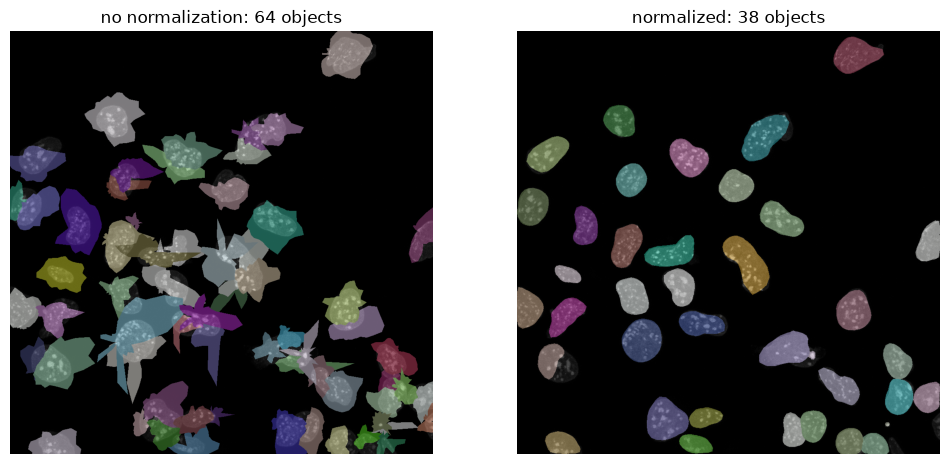

In [2]:
# Predict on the raw (unnormalized) image, same scale as before
labels_raw, _ = model.predict_instances(img_nuclei, scale=0.5)
print(f"raw image       : {labels_raw.max()} objects")
print(f"normalized image: {labels.max()} objects")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
_ = axs[0].imshow(img_nuclei, cmap="gray")
_ = axs[0].imshow(labels_raw, cmap=lbl_cmap, alpha=0.5)
_ = axs[0].set_title(f"no normalization: {labels_raw.max()} objects")
_ = axs[1].imshow(img_nuclei, cmap="gray")
_ = axs[1].imshow(labels, cmap=lbl_cmap, alpha=0.5)
_ = axs[1].set_title(f"normalized: {labels.max()} objects")
for ax in axs:
    _ = ax.axis("off")

The network was trained on images with intensities between roughly 0 and 1, while our
raw image contains values between 3 and 208. The numbers entering the network are then
far outside the range it has seen, and the prediction is unreliable.

Normalization also makes the result independent of exposure time: an image taken twice
as bright gives the same input to the network after normalization.

## Exercise: Which scale works best?

Count the objects for a range of scales and look at where the curve flattens out.

scale 0.05 ->    2 objects
scale 0.10 ->   34 objects
scale 0.20 ->   36 objects
scale 0.30 ->   36 objects
scale 0.40 ->   37 objects
scale 0.50 ->   38 objects
scale 0.60 ->   45 objects
scale 0.75 ->   68 objects
scale 1.00 ->  238 objects


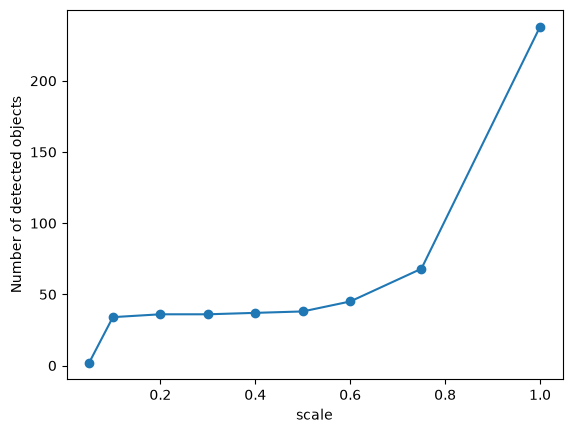

In [5]:
scales = [0.05,0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]
counts = []

for s in scales:
    lab, _ = model.predict_instances(img_nuclei_norm, scale=s)
    counts.append(lab.max())
    print(f"scale {s:4.2f} -> {lab.max():4d} objects")

_ = plt.plot(scales, counts, "o-")
_ = plt.xlabel("scale")
_ = plt.ylabel("Number of detected objects")

Between 0.2 and 0.5 the count barely changes (36 to 38 objects). From 0.6 upwards it
climbs steeply, because single nuclei are broken into fragments.

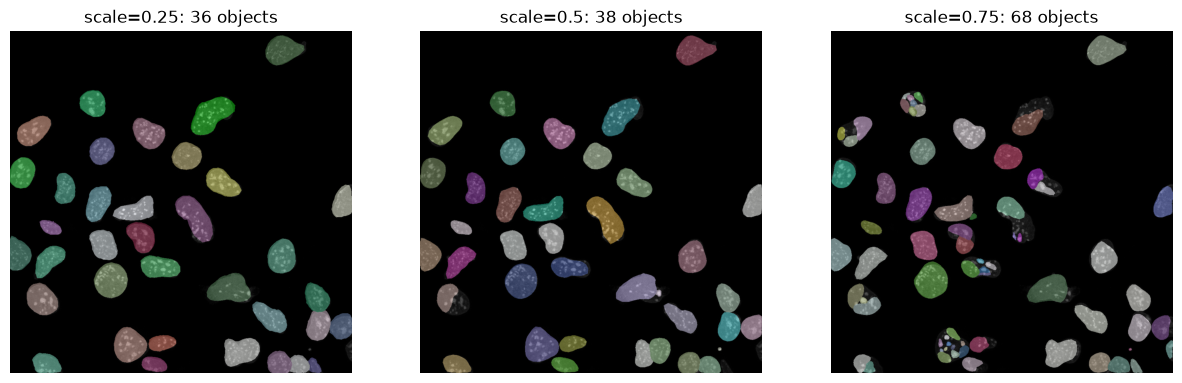

In [4]:
# Look at the two ends of the curve next to the value we chose
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, s in zip(axs, [0.25, 0.5, 0.75]):
    lab, _ = model.predict_instances(img_nuclei_norm, scale=s)
    _ = ax.imshow(img_nuclei, cmap="gray")
    _ = ax.imshow(lab, cmap=lbl_cmap, alpha=0.5)
    _ = ax.set_title(f"scale={s}: {lab.max()} objects")
    _ = ax.axis("off")